<a href="https://colab.research.google.com/github/adityab-tech/Machine-Unlearning/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q datasets transformers

In [5]:
from datasets import load_dataset
from PIL import Image
from collections import Counter

In [6]:
dataset = load_dataset("flaviagiammarino/vqa-rad")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import sys

In [8]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})


In [10]:
print(dataset["train"][0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=566x555 at 0x7C5AA858C050>, 'question': 'are regions of the brain infarcted?', 'answer': 'yes'}


are regions of the brain infarcted?
yes


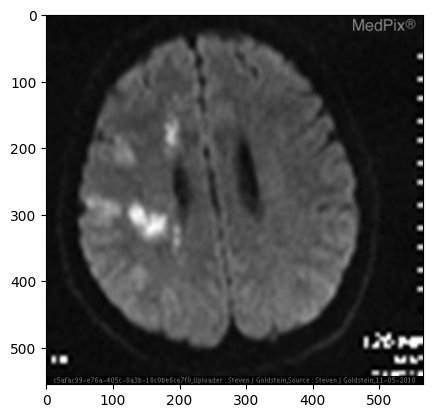

In [17]:
sample = dataset["train"][0]
plt.imshow(sample["image"])
#plt.axis("off")
print(sample["question"])
print(sample["answer"])

In [12]:
for i in range(5):
    print(dataset["train"][i]["image"].size)

(566, 555)
(480, 503)
(1024, 1291)
(766, 978)
(555, 693)


In [18]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [19]:
train_df.head()

,image,question,answer
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are regions of the brain infarcted?,yes
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are the lungs normal appearing?,no
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,which organ system is abnormal in this image?,cardiovascular
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is the lesion causing significant brainstem he...,no
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,how was this image taken?,mri


In [20]:
train_df.isnull().sum()

,0
image,0
question,0
answer,0


In [21]:
train_df.describe()

,image,question,answer
count,1793,1793,1793
unique,1793,1583,432
top,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is the heart enlarged?,no
freq,1,12,473


In [22]:
train_df["question_length"] = train_df["question"].apply(
    lambda x: len(x.split())
)
train_df["question_length"].describe()

,question_length
count,1793.000000
mean,6.799219
std,2.428638
min,3.000000
25%,5.000000
50%,6.000000
75%,8.000000
max,21.000000


In [26]:
train_df["answer"].value_counts().head(20)

,count
answer,
no,473
yes,467
axial,31
right,20
pa,14
left,13
ct,10
brain,8
diffuse,7


In [27]:
train_df["answer_length"] = train_df["answer"].apply(
    lambda x: len(str(x).split())
)
train_df["answer_length"].describe()

,answer_length
count,1793.000000
mean,1.626882
std,1.538092
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


In [28]:
def question_type(question):
    q = question.lower()
    closed_words = ("is","are","does","do","can","was","were","has","have")
    if q.startswith(closed_words):
        return "closed"
    return "open"

In [29]:
train_df["type"] = train_df["question"].apply(question_type)
test_df["type"] = test_df["question"].apply(question_type)

In [31]:
train_df.head(50)

,image,question,answer,question_length,answer_length,type
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are regions of the brain infarcted?,yes,6,1,closed
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are the lungs normal appearing?,no,5,1,closed
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,which organ system is abnormal in this image?,cardiovascular,8,1,open
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is the lesion causing significant brainstem he...,no,7,1,closed
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,how was this image taken?,mri,5,1,open
5,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,what is the condition of the patient,blind loop syndrome,7,3,open
6,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,what abnormality is seen?,blind-ending loop of bowel arising from the cecum,4,8,open
7,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,what is the location of the mass?,pineal region,7,2,open
8,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,where is the mass?,pineal region,4,2,open
9,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is this image in the transverse plane?,yes,7,1,closed


In [32]:
train_df["type"].value_counts()

,count
type,
closed,1015
open,778


In [34]:
train_df.drop(columns=["image"]).to_csv(
    "train_metadata.csv",
    index=False
)

test_df.drop(columns=["image"]).to_csv(
    "test_metadata.csv",
    index=False
)

In [35]:
dataset.save_to_disk("vqa_rad_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/1793 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/451 [00:00<?, ? examples/s]